# Day 25 — Space
### #30DayChartChallenge | April 2026

**The Blind Spot in Our Maps of Other Worlds**  
A hexbin density chart of 6,000+ confirmed exoplanets plotted by orbital period and planet size.  
The empty region at bottom-right is not empty space — it is where our instruments cannot yet see.

**Data:** NASA Exoplanet Archive — Planetary Systems Composite Parameters (pscomppars)  
**Author:** Sharfudeen Yasar Arafath

In [1]:
library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(scales)

font_add_google("Outfit", "outfit")
font_add_google("JetBrains Mono", "jetbrains")
font_add_google("Roboto Condensed", "roboto_condensed")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 12, repr.plot.height = 9, repr.plot.res = 300)


Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Loading required package: sysfonts



Loading required package: showtextdb



In [2]:
df_raw <- read.csv("../../data/day_25/nasa_exoplanets.csv")

df <- df_raw |>
  filter(
    !is.na(pl_rade), pl_rade > 0,
    !is.na(pl_orbper), pl_orbper > 0
  ) |>
  filter(pl_rade <= 25, pl_orbper <= 1000)

cat("Planets plotted:", nrow(df), "\n")

Planets plotted: 5498 


Warning message:
"package 'hexbin' was built under R version 4.5.3"


Warning message:
"Removed 25 rows containing non-finite outside the scale range
(`stat_binhex()`)."


Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_hex()`)."


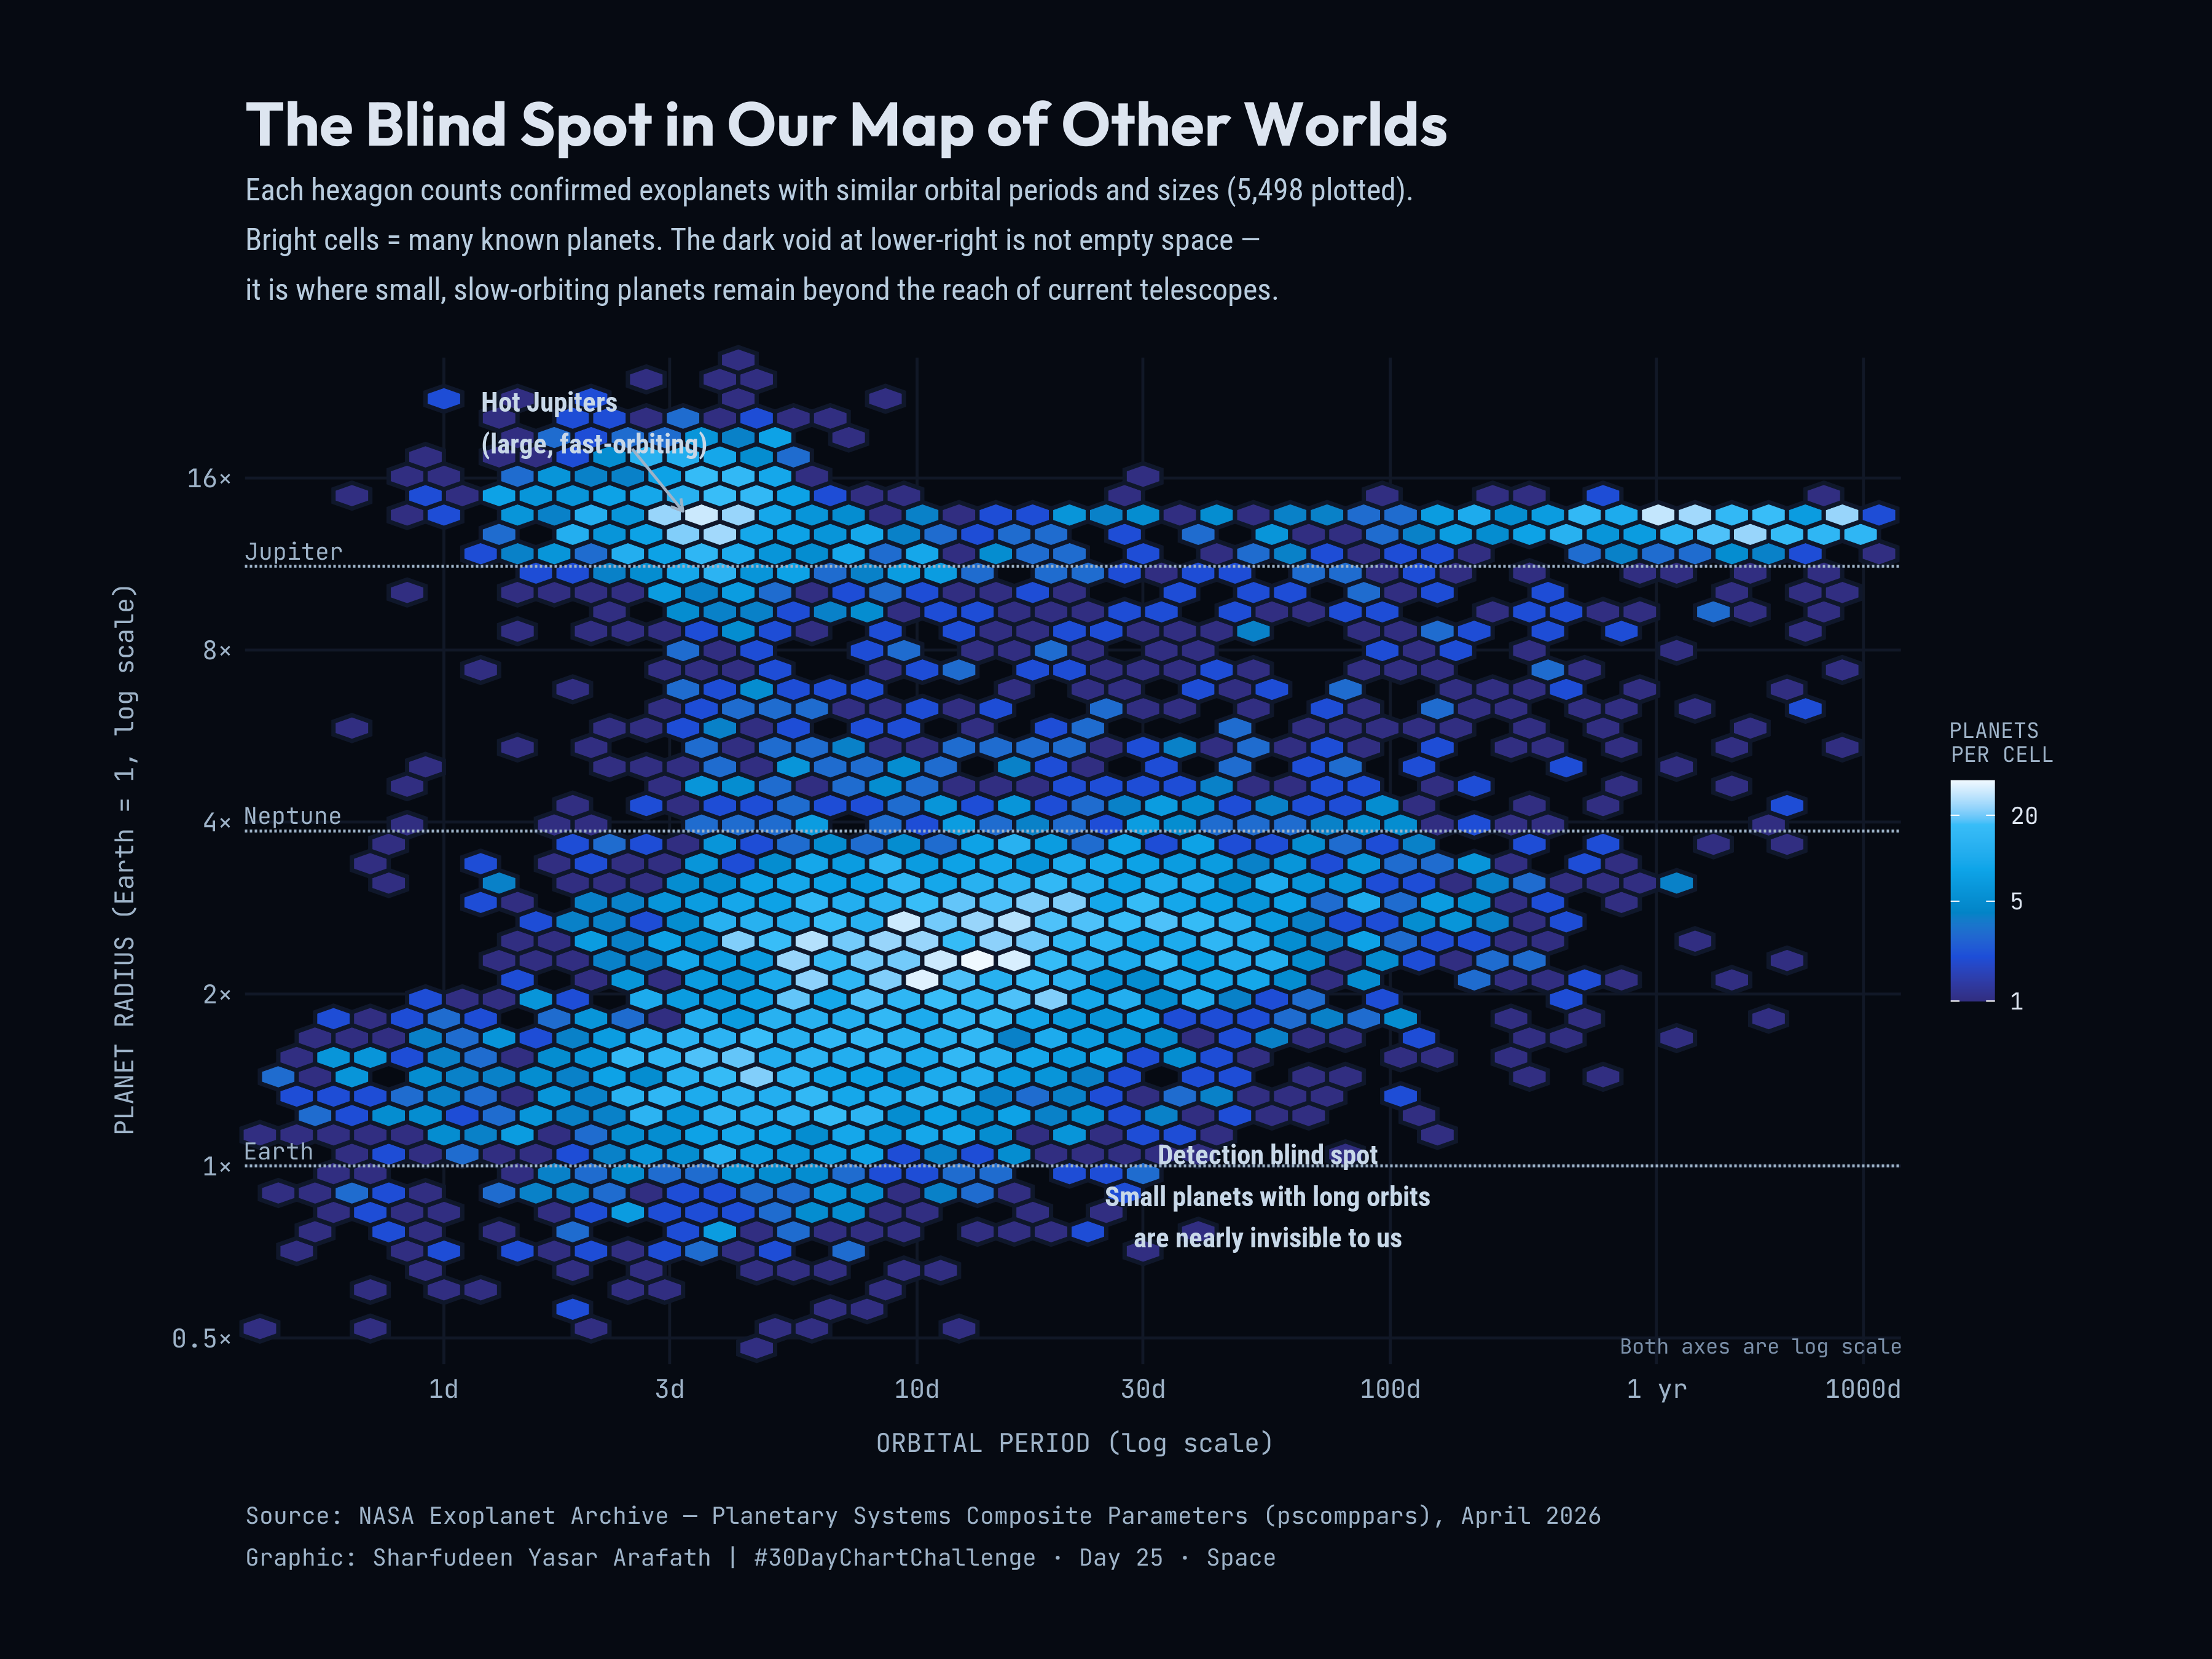

In [3]:
library(hexbin)

bg_col   <- "#060a12"
text_col <- "#dde5f0"
subtext  <- "#9eb3c8"
grid_col <- "#111827"

earth_r   <- 1.0
neptune_r <- 3.86
jupiter_r <- 11.21

p <- ggplot(df, aes(x = pl_orbper, y = pl_rade)) +

  geom_hex(bins = 45, colour = "#0f172a") +
  scale_fill_gradientn(
    colours = c("#312e81", "#1d4ed8", "#0284c7", "#0ea5e9", "#38bdf8", "#f0f9ff"),
    name    = "PLANETS\nPER CELL",
    trans   = "log10",
    breaks  = c(1, 5, 20, 100, 400),
    labels  = c("1", "5", "20", "100", "400+")
  ) +

  geom_hline(yintercept = earth_r,   colour = subtext, linewidth = 0.4, linetype = "dashed") +
  geom_hline(yintercept = neptune_r, colour = subtext, linewidth = 0.4, linetype = "dashed") +
  geom_hline(yintercept = jupiter_r, colour = subtext, linewidth = 0.4, linetype = "dashed") +

  annotate("text", x = 0.38, y = earth_r,
           label = "Earth",   hjust = 0, vjust = -0.4,
           size = 3.2, colour = subtext, family = "jetbrains") +
  annotate("text", x = 0.38, y = neptune_r,
           label = "Neptune", hjust = 0, vjust = -0.4,
           size = 3.2, colour = subtext, family = "jetbrains") +
  annotate("text", x = 0.38, y = jupiter_r,
           label = "Jupiter", hjust = 0, vjust = -0.4,
           size = 3.2, colour = subtext, family = "jetbrains") +

  # Hot Jupiter callout — bold and bright
  annotate("text", x = 1.2, y = 20,
           label = "Hot Jupiters\n(large, fast-orbiting)",
           hjust = 0, size = 3.8, colour = "#c8d8e8", fontface = "bold",
           family = "roboto_condensed", lineheight = 1.25) +
  annotate("segment", x = 2.5, xend = 3.2, y = 18, yend = 14,
           colour = subtext, linewidth = 0.4,
           arrow = arrow(length = unit(0.07, "inches"), type = "open")) +

  # Detection blind-spot callout — bold and bright
  annotate("text", x = 55, y = 0.72,
           label = "Detection blind spot\nSmall planets with long orbits\nare nearly invisible to us",
           hjust = 0.5, vjust = 0, size = 3.8, colour = "#c8d8e8", fontface = "bold",
           family = "roboto_condensed", lineheight = 1.25) +

  annotate("text", x = 1200, y = 0.47,
           label = "Both axes are log scale",
           hjust = 1, vjust = 0, size = 2.9, colour = "#7a8fa8",
           family = "jetbrains") +

  scale_x_log10(
    breaks = c(1, 3, 10, 30, 100, 365, 1000),
    labels = c("1d", "3d", "10d", "30d", "100d", "1 yr", "1000d"),
    limits = c(0.38, 1200),
    expand = expansion(mult = c(0, 0))
  ) +
  scale_y_log10(
    breaks = c(0.5, 1, 2, 4, 8, 16),
    labels = c("0.5×", "1×", "2×", "4×", "8×", "16×"),
    limits = c(0.45, 26),
    expand = expansion(mult = c(0, 0))
  ) +

  coord_cartesian(clip = "off") +

  labs(
    title    = "The Blind Spot in Our Map of Other Worlds",
    subtitle = paste0(
      "Each hexagon counts confirmed exoplanets with similar orbital periods and sizes (5,498 plotted).\n",
      "Bright cells = many known planets. The dark void at lower-right is not empty space —\n",
      "it is where small, slow-orbiting planets remain beyond the reach of current telescopes."
    ),
    x       = "ORBITAL PERIOD (log scale)",
    y       = "PLANET RADIUS (Earth = 1, log scale)",
    caption = "Source: NASA Exoplanet Archive — Planetary Systems Composite Parameters (pscomppars), April 2026\nGraphic: Sharfudeen Yasar Arafath | #30DayChartChallenge · Day 25 · Space"
  ) +

  theme_minimal(base_family = "outfit", base_size = 13) +
  theme(
    plot.background    = element_rect(fill = bg_col, colour = NA),
    panel.background   = element_rect(fill = bg_col, colour = NA),
    panel.grid.major   = element_line(colour = grid_col, linewidth = 0.4),
    panel.grid.minor   = element_blank(),

    plot.title    = element_text(family = "outfit", face = "bold", size = 24,
                                 colour = text_col, margin = margin(b = 8)),
    plot.subtitle = element_text(family = "roboto_condensed", size = 12,
                                 colour = "#b8ccde", lineheight = 1.35, margin = margin(b = 20)),
    plot.caption  = element_text(family = "jetbrains", size = 9, colour = "#9eb3c8",
                                 hjust = 0, lineheight = 1.5, margin = margin(t = 20)),

    axis.text    = element_text(family = "jetbrains", size = 10, colour = subtext),
    axis.title.x = element_text(family = "jetbrains", size = 10, colour = subtext, margin = margin(t = 12)),
    axis.title.y = element_text(family = "jetbrains", size = 10, colour = subtext, margin = margin(r = 12)),

    legend.background = element_rect(fill = bg_col, colour = NA),
    legend.key        = element_rect(fill = bg_col, colour = NA),
    legend.title      = element_text(family = "jetbrains", size = 8.5, colour = subtext),
    legend.text       = element_text(family = "jetbrains", size = 9, colour = text_col),
    legend.position   = "right",

    plot.margin = margin(40, 55, 35, 45)
  )

p

In [4]:
ggsave("../../chart/day_25_space.png", plot = p,
       width = 12, height = 9, dpi = 300, bg = bg_col)
cat("\u2705 Day 25 Space hexbin chart saved\n")

Warning message:
"Removed 25 rows containing non-finite outside the scale range
(`stat_binhex()`)."


Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_hex()`)."


✅ Day 25 Space hexbin chart saved
